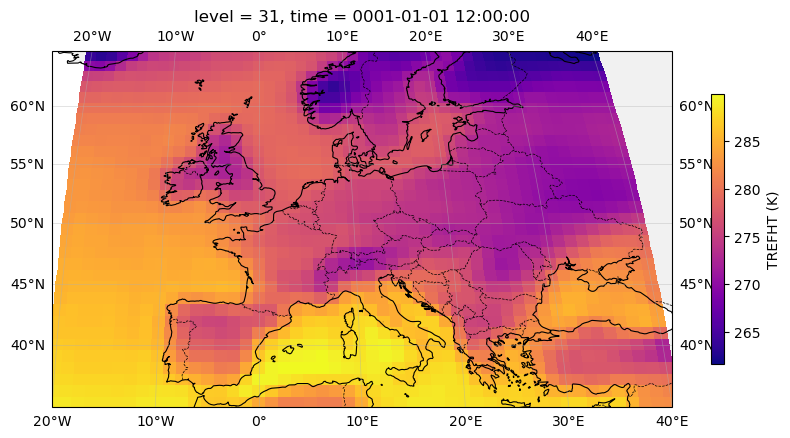

In [6]:
# note to myself: pip install cartopy netcdf4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature


cam_data = xr.open_dataset('sample_data_camulator.nc')
"""
# Tests from slides:
## View all variables
print("Variables:", list(cam_data.data_vars))
## View dimensions
print("\nDimensions:", dict(cam_data.dims))
## View coordinates
print("\nCoordinates:", list(cam_data.coords))
## Global attributes
print("\nGlobal attributes:", cam_data.attrs)
## Specific variable attributes
print("\nTREFHT attributes:", cam_data['TREFHT'].attrs)
"""
# shift longitude to -180 to 180 to allow slicing across meridian 
cam_data.coords['longitude'] = (cam_data.coords['longitude'] + 180) % 360 - 180
cam_data = cam_data.sortby(cam_data.longitude)

#lat: 35-65N
#long 20W-40E
europe = cam_data.sel(
    latitude=slice(35,65),
    longitude=slice(-20,40)
)

# Plot original values:
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.Robinson()}   # 1. Choose map projection
)
europe['TREFHT'].isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),                # data is on regular lat/lon
    cmap='plasma',
    cbar_kwargs={'label': 'TREFHT (K)', 'shrink': 0.7},  
)
ax.set_extent([-20, 40, 35, 65], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Lab Plotting: